# LDA Implementation from Scratch

This notebook implements Linear Discriminant Analysis (LDA) manually using NumPy and visualizes the projected data.

In [3]:
!pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable


In [4]:
def lda_from_scratch(X, y, k=1):
    classes = np.unique(y)
    n_features = X.shape[1]
    overall_mean = np.mean(X, axis=0)

    # 1. Class-wise means
    class_means = []
    for c in classes:
        X_c = X[y == c]
        class_means.append(np.mean(X_c, axis=0))
    class_means = np.array(class_means)

    # 2. Within-Class Scatter Matrix (Sw)
    Sw = np.zeros((n_features, n_features))
    for i, c in enumerate(classes):
        X_c = X[y == c]
        diff = X_c - class_means[i]
        Sw += diff.T @ diff

    # 3. Between-Class Scatter Matrix (Sb)
    Sb = np.zeros((n_features, n_features))
    for i, c in enumerate(classes):
        X_c = X[y == c]
        n_c = len(X_c)
        diff = class_means[i] - overall_mean
        Sb += n_c * np.outer(diff, diff)

    # 4. Solve generalized eigenvalue problem: Sw^-1 Sb
    eps = 1e-5
    Sw_reg = Sw + eps * np.eye(n_features)
    eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw_reg) @ Sb)

    # 5. Select top k eigenvectors
    idx = np.argsort(eigvals)[::-1][:k]
    W = eigvecs[:, idx]

    # 6. Project the data
    X_lda = X @ W
    return X_lda, W, eigvals

In [5]:
np.random.seed(42)
class_0 = np.random.randn(50, 2) + np.array([0, 0])
class_1 = np.random.randn(50, 2) + np.array([4, 4])
class_2 = np.random.randn(50, 2) + np.array([0, 6])

X = np.vstack([class_0, class_1, class_2])
y = np.array([0] * 50 + [1] * 50 + [2] * 50)

X_lda, W, eigvals = lda_from_scratch(X, y, k=2)
print('Projected shape:', X_lda.shape)
print('Top eigenvalues:', np.sort(eigvals)[::-1][:3])
print('Projection matrix shape:', W.shape)

Projected shape: (150, 2)
Top eigenvalues: [7.13432939 3.1345407 ]
Projection matrix shape: (2, 2)


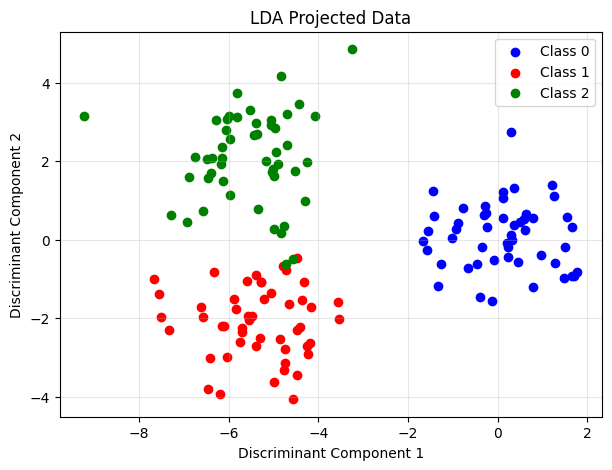

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(X_lda[:50, 0], X_lda[:50, 1], color='blue', label='Class 0')
plt.scatter(X_lda[50:100, 0], X_lda[50:100, 1], color='red', label='Class 1')
plt.scatter(X_lda[100:, 0], X_lda[100:, 1], color='green', label='Class 2')
plt.title('LDA Projected Data')
plt.xlabel('Discriminant Component 1')
plt.ylabel('Discriminant Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Explanation

- `Sw` = Within-Class Scatter Matrix: measures how spread out the samples are inside each class.
- `Sb` = Between-Class Scatter Matrix: measures how far the class means are from the overall mean.
- The eigenvectors of `Sw^-1 Sb` give the discriminant directions that maximize class separability.
- Projecting the data onto these directions reduces the dimensionality while keeping the class information.